In [ ]:
"""
Simple GAN for MNIST Zeros
--------------------------

This notebook trains a simple Generative Adversarial Network (GAN) to generate
handwritten digits "0" from the MNIST dataset.

Highlights:
- Data filtering for single-class GAN (digits=0)
- Basic generator and discriminator networks
- Custom GAN training loop
"""

# Core Libraries
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, Flatten
from tensorflow.keras.datasets import mnist

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


Filtered dataset shape: (5923, 28, 28)


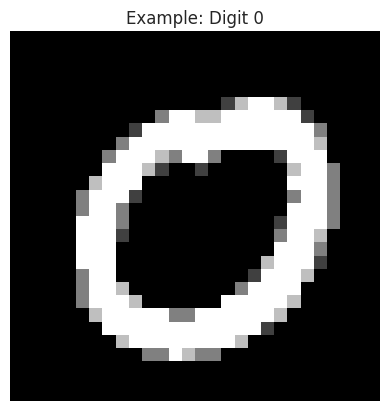

In [2]:
(X_train, y_train), (_, _) = mnist.load_data()

# Filter for only zeros
only_zeros = X_train[y_train == 0]
print(f"Filtered dataset shape: {only_zeros.shape}")

# Display a sample
plt.imshow(only_zeros[950], cmap='gray')
plt.title("Example: Digit 0")
plt.axis('off')
plt.show()


In [ ]:
codings_size = 100

generator = Sequential([
    Dense(100, activation="relu", input_shape=[codings_size]),
    Dense(150, activation="relu"),
    Dense(784, activation="sigmoid"),
    Reshape([28, 28])
])


In [ ]:
discriminator = Sequential([
    Flatten(input_shape=[28, 28]),
    Dense(150, activation="relu"),
    Dense(100, activation="relu"),
    Dense(1, activation="sigmoid")
])

discriminator.compile(loss="binary_crossentropy", optimizer="adam")


In [ ]:
discriminator.trainable = False

GAN = Sequential([generator, discriminator])
GAN.compile(loss="binary_crossentropy", optimizer="adam")


In [ ]:
print(GAN.summary())


In [ ]:
batch_size = 32

# Build a tf.data.Dataset
dataset = tf.data.Dataset.from_tensor_slices(only_zeros)
dataset = dataset.shuffle(buffer_size=1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)


In [ ]:
# Separate models
generator, discriminator = GAN.layers

epochs = 1  # For demo, you can raise this

for epoch in range(epochs):
    print(f"Starting Epoch {epoch+1}")
    for step, X_batch in enumerate(dataset):

        # --- Train Discriminator ---
        noise = tf.random.normal(shape=[batch_size, codings_size])
        gen_images = generator(noise)

        X_fake_vs_real = tf.concat([gen_images, tf.cast(X_batch, tf.float32)], axis=0)
        y1 = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)

        discriminator.trainable = True
        discriminator.train_on_batch(X_fake_vs_real, y1)

        # --- Train Generator ---
        noise = tf.random.normal(shape=[batch_size, codings_size])
        y2 = tf.constant([[1.]] * batch_size)

        discriminator.trainable = False
        GAN.train_on_batch(noise, y2)

    print(f"Finished Epoch {epoch+1}")

print("Training complete.")


In [ ]:
noise = tf.random.normal(shape=[10, codings_size])
generated_images = generator(noise)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for img, ax in zip(generated_images, axes.flatten()):
    ax.imshow(img.numpy(), cmap="gray")
    ax.axis("off")

plt.suptitle("Generated Zeros")
plt.show()
